# Decision Trees

### We will be using the data set of a client leaving a telecom company which we used for K-Nearest Neighbors method exercises

1.png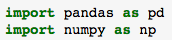

In [1]:
import pandas as pd
import numpy as np

2.png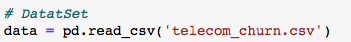

In [2]:
data = pd.read_csv('telecom_churn.csv')


3.png

In [3]:
data.head()


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


4.png

In [4]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   3333 non-null   object 
 1   Account length          3333 non-null   int64  
 2   Area code               3333 non-null   int64  
 3   International plan      3333 non-null   object 
 4   Voice mail plan         3333 non-null   object 
 5   Number vmail messages   3333 non-null   int64  
 6   Total day minutes       3333 non-null   float64
 7   Total day calls         3333 non-null   int64  
 8   Total day charge        3333 non-null   float64
 9   Total eve minutes       3333 non-null   float64
 10  Total eve calls         3333 non-null   int64  
 11  Total eve charge        3333 non-null   float64
 12  Total night minutes     3333 non-null   float64
 13  Total night calls       3333 non-null   int64  
 14  Total night charge      3333 non-null   

In [5]:
# We do not have NaNs
# Churn - This is an answer column : did the client leave or not

In [6]:
# You can type the code from the next cell or create the loop code by yourself

5.png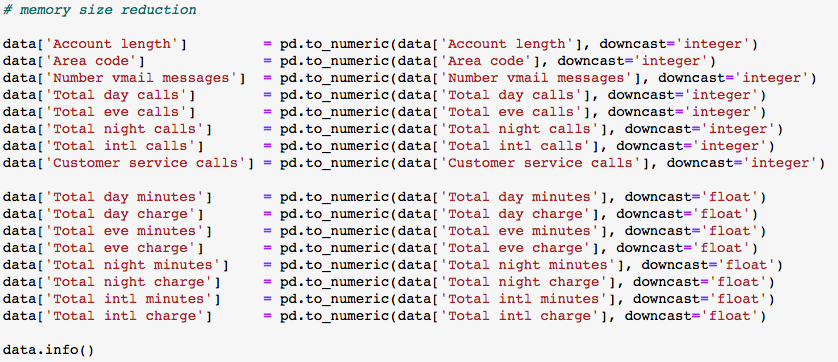

In [7]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   3333 non-null   object 
 1   Account length          3333 non-null   int64  
 2   Area code               3333 non-null   int64  
 3   International plan      3333 non-null   object 
 4   Voice mail plan         3333 non-null   object 
 5   Number vmail messages   3333 non-null   int64  
 6   Total day minutes       3333 non-null   float64
 7   Total day calls         3333 non-null   int64  
 8   Total day charge        3333 non-null   float64
 9   Total eve minutes       3333 non-null   float64
 10  Total eve calls         3333 non-null   int64  
 11  Total eve charge        3333 non-null   float64
 12  Total night minutes     3333 non-null   float64
 13  Total night calls       3333 non-null   int64  
 14  Total night charge      3333 non-null   

In [8]:
# We reduced the memory size more than two times

6.png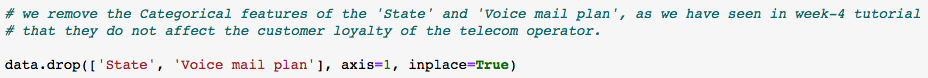

In [9]:
data.drop(['State', 'Voice mail plan'], axis=1, inplace=True)


7.png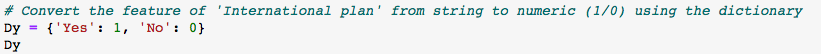

In [10]:
Dy = {'Yes': 1, 'No': 0}
print(Dy)

{'Yes': 1, 'No': 0}


8.png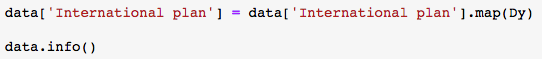

In [11]:
data['International plan'] = data['International plan'].map(Dy)


In [12]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Account length          3333 non-null   int64  
 1   Area code               3333 non-null   int64  
 2   International plan      3333 non-null   int64  
 3   Number vmail messages   3333 non-null   int64  
 4   Total day minutes       3333 non-null   float64
 5   Total day calls         3333 non-null   int64  
 6   Total day charge        3333 non-null   float64
 7   Total eve minutes       3333 non-null   float64
 8   Total eve calls         3333 non-null   int64  
 9   Total eve charge        3333 non-null   float64
 10  Total night minutes     3333 non-null   float64
 11  Total night calls       3333 non-null   int64  
 12  Total night charge      3333 non-null   float64
 13  Total intl minutes      3333 non-null   float64
 14  Total intl calls        3333 non-null   

In [13]:
# All features are numerical. Target is Boolean

In [14]:
# splitting data into 'Input' and 'Output' parameters

9.png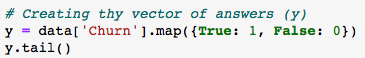

In [15]:
y = data['Churn'].map({True: 1, False: 0})
y.tail()

3328    0
3329    0
3330    0
3331    0
3332    0
Name: Churn, dtype: int64

10.png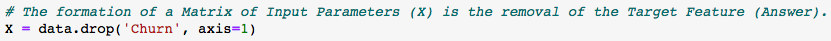

In [16]:
X = data.drop('Churn', axis=1)


11.png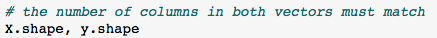

In [17]:
X.shape, y.shape


((3333, 17), (3333,))

### Separate data into training, validation and testing parts

12.png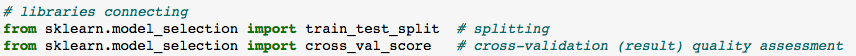

In [18]:
from sklearn.model_selection import train_test_split  # splitting
from sklearn.model_selection import cross_val_score 

13.png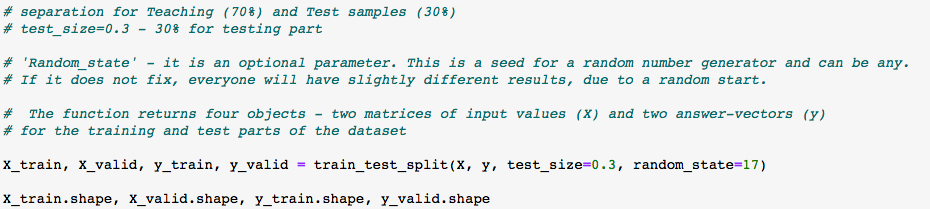

In [19]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3, random_state=17)


In [20]:
# 2333 rows for trening and 1000 rows for testing

## Creating the trees

14.png

In [21]:
from sklearn.tree import DecisionTreeClassifier


15.png

In [22]:
DecisionTreeClassifier?


Init signature:
DecisionTreeClassifier(
    *,
    criterion='gini',
    splitter='best',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,
    max_features=None,
    random_state=None,
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    class_weight=None,
    ccp_alpha=0.0,
    monotonic_cst=None,
)
Docstring:     
A decision tree classifier.

Read more in the :ref:`User Guide <tree>`.

Parameters
----------
criterion : {"gini", "entropy", "log_loss"}, default="gini"
    The function to measure the quality of a split. Supported criteria are
    "gini" for the Gini impurity and "log_loss" and "entropy" both for the
    Shannon information gain, see :ref:`tree_mathematical_formulation`.

splitter : {"best", "random"}, default="best"
    The strategy used to choose the split at each node. Supported
    strategies are "best" to choose the best split and "random" to choose
    the best random split.

max_depth : int, default=None

16.png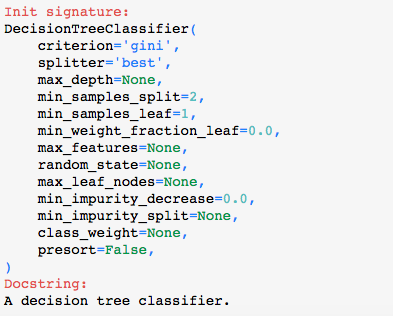

### The first Tree

17.png

In [23]:
first_tree = DecisionTreeClassifier(random_state=17)

18.png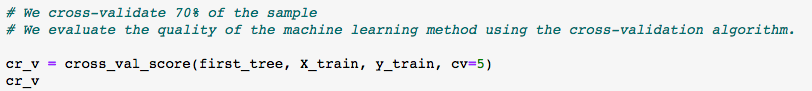

In [24]:
cr_v = cross_val_score(first_tree, X_train, y_train, cv=5)
cr_v

array([0.9143469 , 0.91220557, 0.92077088, 0.90772532, 0.91416309])

19.png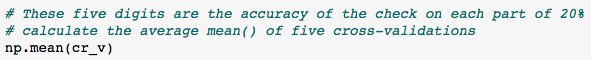

In [25]:
np.mean(cr_v)


np.float64(0.9138423504976518)

In [26]:
# Do you remember the quality of K-Nearest Neighbors method ?
# It was:    0.8671

20.png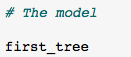

In [27]:
first_tree


DecisionTreeClassifier(random_state=17)

In [28]:
print(first_tree.max_depth)


None


In [29]:
# max_depth=None - unlimited
# Therefore this tree is built to the maximum depth
# In this case, we almost always have overfitting
# Possibly improve the model by reducing the depth of the tree

### Searching for optimal tree depth without overfitting

21.png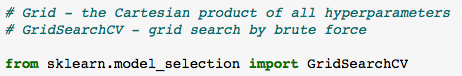

In [30]:
from sklearn.model_selection import GridSearchCV


22.png

In [31]:
GridSearchCV?


Init signature:
GridSearchCV(
    estimator,
    param_grid,
    *,
    scoring=None,
    n_jobs=None,
    refit=True,
    cv=None,
    verbose=0,
    pre_dispatch='2*n_jobs',
    error_score=nan,
    return_train_score=False,
)
Docstring:     
Exhaustive search over specified parameter values for an estimator.

Important members are fit, predict.

GridSearchCV implements a "fit" and a "score" method.
It also implements "score_samples", "predict", "predict_proba",
"decision_function", "transform" and "inverse_transform" if they are
implemented in the estimator used.

The parameters of the estimator used to apply these methods are optimized
by cross-validated grid-search over a parameter grid.

Read more in the :ref:`User Guide <grid_search>`.

Parameters
----------
estimator : estimator object
    This is assumed to implement the scikit-learn estimator interface.
    Either estimator needs to provide a ``score`` function,
    or ``scoring`` must be passed.

param_grid : dict or list of

23.png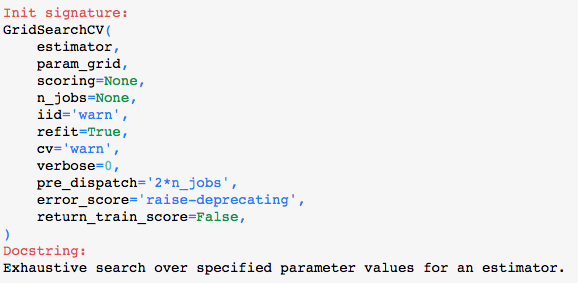

24.png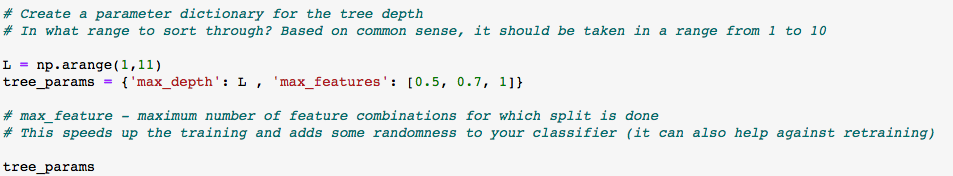

In [32]:
L = np.arange(1, 11)
tree_params = {'max_depth': L, 'max_features': [0.5, 0.7, 1]}

In [33]:
tree_params


{'max_depth': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10]),
 'max_features': [0.5, 0.7, 1]}

25.png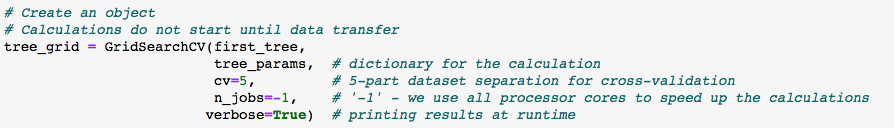

In [34]:
tree_grid = GridSearchCV(first_tree,
    tree_params,  # dictionary for the calculation
    cv=5,         # 5-fold cross-validation
    n_jobs=-1,    # '-1' - use all processor cores to speed up calculations
    verbose=True)

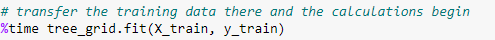

In [35]:
%time tree_grid.fit(X_train, y_train)


Fitting 5 folds for each of 30 candidates, totalling 150 fits
CPU times: total: 375 ms
Wall time: 14.6 s


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=17), n_jobs=-1,
             param_grid={'max_depth': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10]),
                         'max_features': [0.5, 0.7, 1]},
             verbose=True)

27.png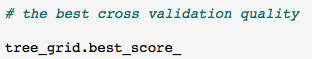

In [36]:
tree_grid.best_score_


np.float64(0.9391366681677404)

In [37]:
# It is better than 0.9138423504976518 for full decision tree depth

28.png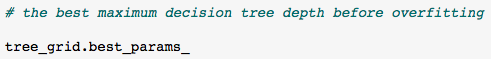

In [38]:
tree_grid.best_params_


{'max_depth': np.int64(6), 'max_features': 0.7}

### Testing

29.png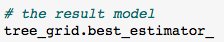

In [39]:
tree_grid.best_estimator_


DecisionTreeClassifier(max_depth=np.int64(6), max_features=0.7, random_state=17)

30.png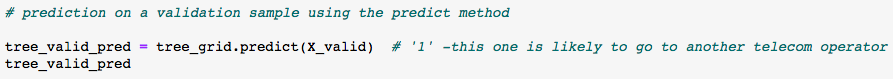

In [40]:
tree_valid_pred = tree_grid.predict(X_valid)
tree_valid_pred

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,

31.png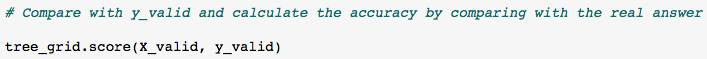

In [41]:
tree_grid.score(X_valid, y_valid)


0.936

### Visualization

32.png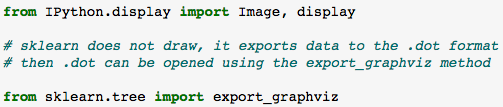

In [42]:
from IPython.display import Image, display
from sklearn.tree import export_graphviz


33.png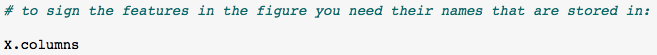

In [43]:
X.columns


Index(['Account length', 'Area code', 'International plan',
       'Number vmail messages', 'Total day minutes', 'Total day calls',
       'Total day charge', 'Total eve minutes', 'Total eve calls',
       'Total eve charge', 'Total night minutes', 'Total night calls',
       'Total night charge', 'Total intl minutes', 'Total intl calls',
       'Total intl charge', 'Customer service calls'],
      dtype='object')

#### Creating a visualisation of the decision tree with optimal depth and number of features

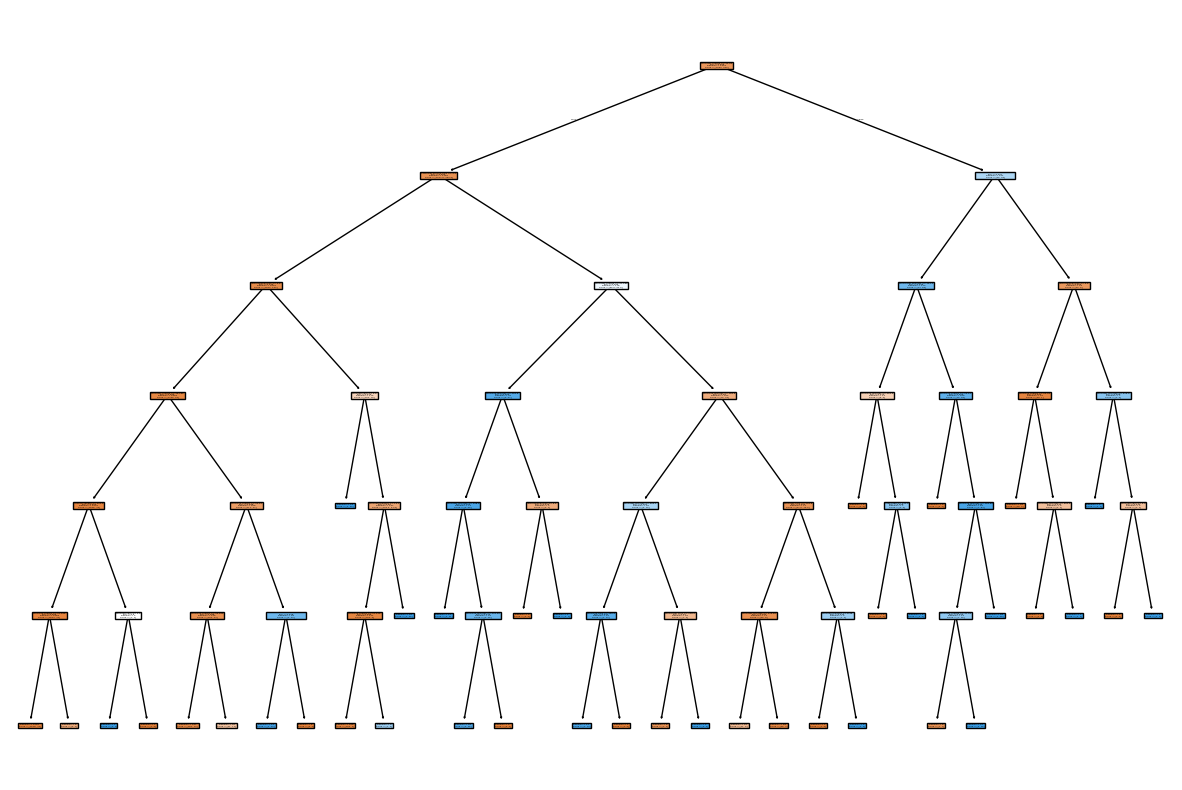

In [44]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
# Plot directly
plt.figure(figsize=(15,10))
plot_tree(
    tree_grid.best_estimator_,
    feature_names=X.columns,
 #   class_names=,
    filled=True,
)
plt.show()

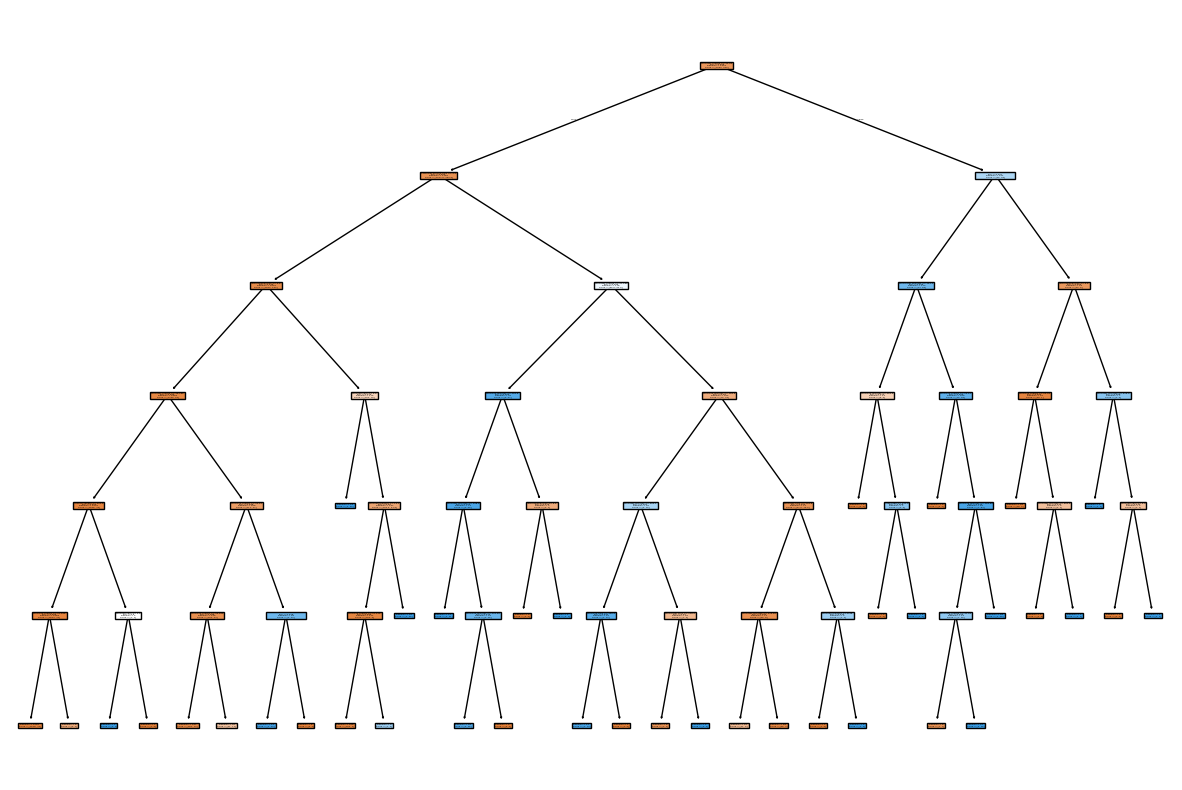

In [45]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Plot directly
plt.figure(figsize=(15,10))
plot_tree(
    tree_grid.best_estimator_,
    feature_names=X.columns,  # Fixed: should be 'columns' not 'Columns'
    # class_names=,  # You can add class names here if needed
    filled=True,
)
plt.show()

![title](tree.png)

Could print the better version of the tree with graphviz. But need to install graphviz binaries separately

34.png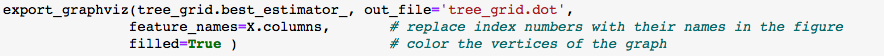

In [50]:
export_graphviz(tree_grid.best_estimator_, 
                out_file='tree_grid.dot',
                feature_names=X.columns,    # Fixed: 'columns' not 'Columns'
                filled=True)

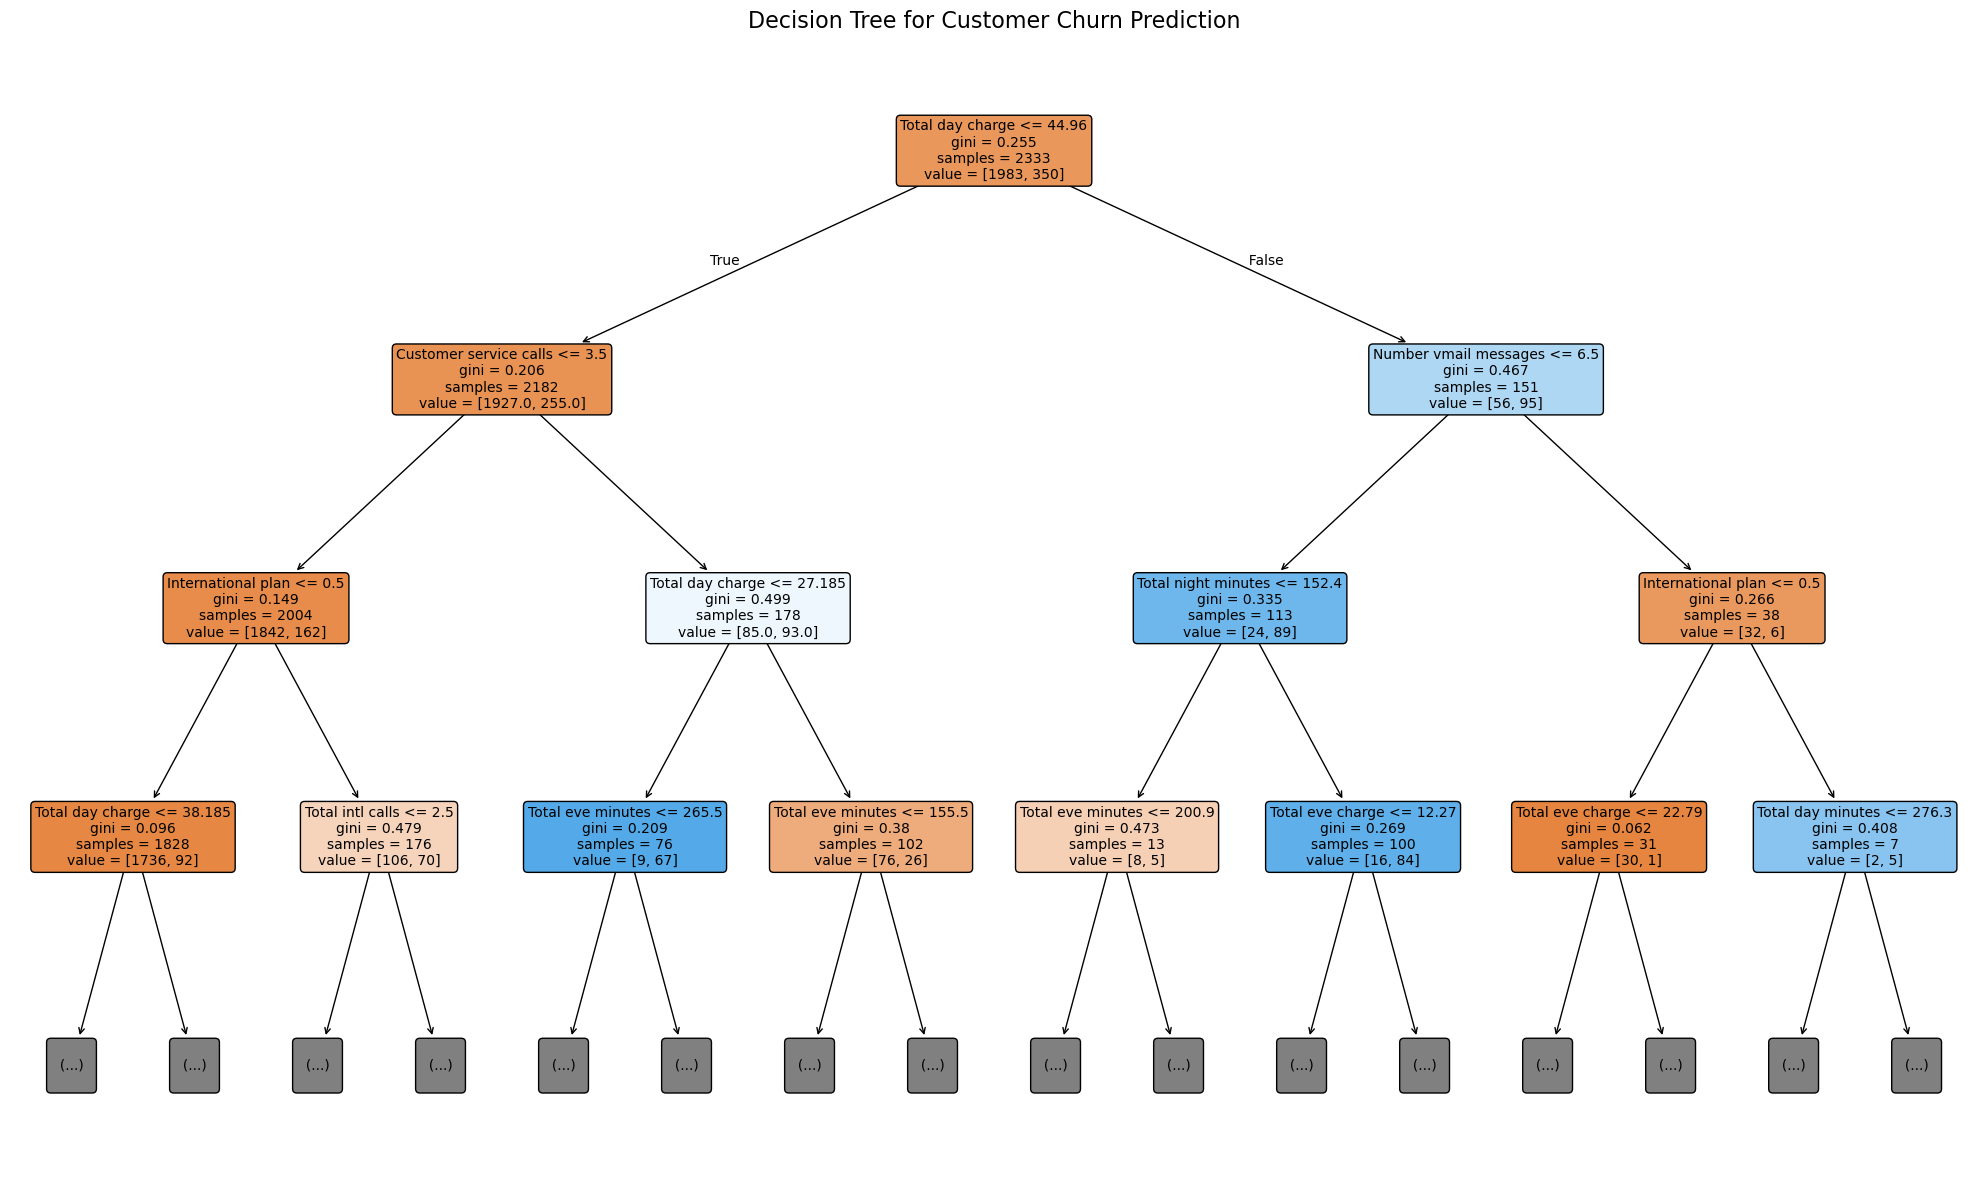

In [53]:
# you can convert .dot to .png file in any way
# you can use online resources, for example (https://convert.world/convert-dot-to-png)
# (just don’t need to download the ad packages - refuse)
# Other option is if the Graphviz binarie(is in the path) and pydotplus is installed, the following code might work.

# pip install pydotplus
plt.figure(figsize=(20, 12))
plot_tree(tree_grid.best_estimator_, 
          feature_names=X.columns.tolist(),
          filled=True,
          rounded=True,
          fontsize=10,
          max_depth=3)  # Show only top 3 levels for clarity
plt.title('Decision Tree for Customer Churn Prediction', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# after this conversion put the .png file into your current directory with this JupyterNoteBook

35.png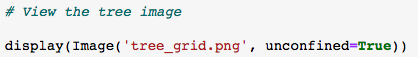

In [54]:
display(Image('tree_grid.png', unconfined=True))


### Random Forest

36.png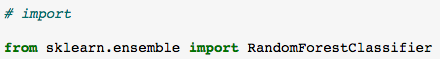

In [55]:
from sklearn.ensemble import RandomForestClassifier


37.png

In [56]:
RandomForestClassifier?


Init signature:
RandomForestClassifier(
    n_estimators=100,
    *,
    criterion='gini',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,
    max_features='sqrt',
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    bootstrap=True,
    oob_score=False,
    n_jobs=None,
    random_state=None,
    verbose=0,
    warm_start=False,
    class_weight=None,
    ccp_alpha=0.0,
    max_samples=None,
    monotonic_cst=None,
)
Docstring:     
A random forest classifier.

A random forest is a meta estimator that fits a number of decision tree
classifiers on various sub-samples of the dataset and uses averaging to
improve the predictive accuracy and control over-fitting.
Trees in the forest use the best split strategy, i.e. equivalent to passing
`splitter="best"` to the underlying :class:`~sklearn.tree.DecisionTreeClassifier`.
The sub-sample size is controlled with the `max_samples` parameter if
`bootstrap=True` (default), otherwise the

38.png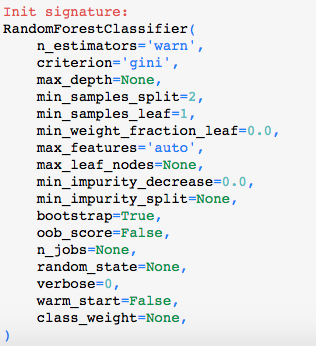

39.png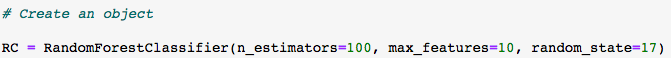

In [57]:
RC = RandomForestClassifier(n_estimators=100, max_features=10, random_state=17)


41.png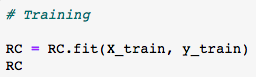

In [59]:
RC = RC.fit(X_train, y_train)
RC

RandomForestClassifier(max_features=10, random_state=17)

42.png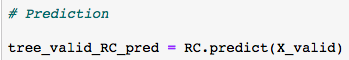

In [60]:
tree_valid_RC_pred = RC.predict(X_valid)


43.png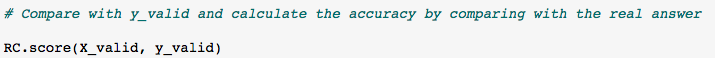

In [61]:
RC.score(X_valid, y_valid)


0.955

44.png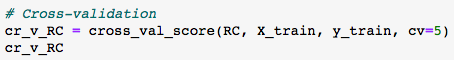

In [62]:
cr_v_RC = cross_val_score(RC, X_train, y_train, cv=5)
cr_v_RC

array([0.94646681, 0.94218415, 0.94218415, 0.9527897 , 0.95708155])

45.png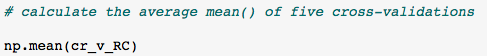

In [63]:
np.mean(cr_v_RC)

np.float64(0.9481412724816426)